In [51]:
import trimesh
import numpy as np

path_to_folder = "E:\\Dropbox\\RCE\\bone_analysis\\Voor_Maurice\\"
input_glb = path_to_folder+r"3D_model\\bun2_rotated.glb"
output_ply = path_to_folder+r"3D_model\\bun2_rotated.ply"


scene = trimesh.load(input_glb, force="scene")

if isinstance(scene, trimesh.Scene):
    meshes = []

    for node_name in scene.graph.nodes_geometry:
        transform, geom_name = scene.graph[node_name]
        geom = scene.geometry[geom_name]

        if isinstance(geom, trimesh.Trimesh) and len(geom.vertices) > 0:
            g = geom.copy()
            g.apply_transform(transform)
            meshes.append(g)

    if not meshes:
        raise ValueError("No valid mesh geometry found in the GLB file.")

    mesh = trimesh.util.concatenate(meshes)

elif isinstance(scene, trimesh.Trimesh):
    mesh = scene.copy()

else:
    raise ValueError("Unsupported GLB content.")


# Convert from glTF Y-up to Z-up
# This is a +90 degree rotation around the X axis:
# x' = x
# y' = -z
# z' = y
y_up_to_z_up = trimesh.transformations.rotation_matrix(
    np.deg2rad(90),
    [1, 0, 0]
)

mesh.apply_transform(y_up_to_z_up)

mesh.export(output_ply)

print(f"Saved: {output_ply}")

Saved: E:\Dropbox\RCE\bone_analysis\Voor_Maurice\3D_model\\bun2_rotated.ply


In [52]:
import math
import rasterio
from rasterio.transform import from_origin


def make_rotation_matrix(axis="x", angle_deg=0):
    angle = np.deg2rad(angle_deg)

    if axis == "x":
        direction = [1, 0, 0]
    elif axis == "y":
        direction = [0, 1, 0]
    elif axis == "z":
        direction = [0, 0, 1]
    else:
        raise ValueError("axis must be 'x', 'y', or 'z'")

    return trimesh.transformations.rotation_matrix(angle, direction)


def make_flip_matrix(flip_x=False, flip_y=False, flip_z=False):
    sx = -1.0 if flip_x else 1.0
    sy = -1.0 if flip_y else 1.0
    sz = -1.0 if flip_z else 1.0

    M = np.eye(4, dtype=float)
    M[0, 0] = sx
    M[1, 1] = sy
    M[2, 2] = sz
    return M


def transform_about_center(mesh, matrix):
    center = mesh.bounding_box.centroid

    T_to_origin = trimesh.transformations.translation_matrix(-center)
    T_back = trimesh.transformations.translation_matrix(center)

    full = T_back @ matrix @ T_to_origin
    mesh.apply_transform(full)
    return mesh


def load_mesh(input_ply):
    mesh = trimesh.load(input_ply, force="mesh")

    if isinstance(mesh, trimesh.Scene):
        meshes = []
        for geom in mesh.geometry.values():
            if isinstance(geom, trimesh.Trimesh) and len(geom.vertices) > 0:
                meshes.append(geom)
        if not meshes:
            raise ValueError("No valid mesh geometry found.")
        mesh = trimesh.util.concatenate(meshes)

    if not isinstance(mesh, trimesh.Trimesh):
        raise ValueError("Could not load mesh.")

    if len(mesh.vertices) == 0:
        raise ValueError("Mesh has no vertices.")

    return mesh


def orient_mesh(
    mesh,
    rotate_axis=None,
    rotate_angle=0,
    flip_x=False,
    flip_y=False,
    flip_z=False
):
    mesh = mesh.copy()

    # Flip first
    if flip_x or flip_y or flip_z:
        F = make_flip_matrix(flip_x=flip_x, flip_y=flip_y, flip_z=flip_z)
        mesh = transform_about_center(mesh, F)

    # Then rotate
    if rotate_axis is not None and rotate_angle != 0:
        R = make_rotation_matrix(axis=rotate_axis, angle_deg=rotate_angle)
        mesh = transform_about_center(mesh, R)

    return mesh


def sample_mesh_surface(mesh, samples=1000000):
    if len(mesh.faces) == 0:
        return np.asarray(mesh.vertices)

    points, _ = trimesh.sample.sample_surface(mesh, samples)
    return points


def points_to_height_raster(points, resolution):
    x = points[:, 0]
    y = points[:, 1]
    z = points[:, 2]

    xmin, xmax = x.min(), x.max()
    ymin, ymax = y.min(), y.max()

    width = max(1, int(math.ceil((xmax - xmin) / resolution)))
    height = max(1, int(math.ceil((ymax - ymin) / resolution)))

    raster = np.full((height, width), np.nan, dtype=np.float32)

    cols = np.floor((x - xmin) / resolution).astype(int)
    rows = np.floor((ymax - y) / resolution).astype(int)

    valid = (
        (cols >= 0) & (cols < width) &
        (rows >= 0) & (rows < height)
    )

    cols = cols[valid]
    rows = rows[valid]
    z = z[valid]

    for r, c, val in zip(rows, cols, z):
        current = raster[r, c]
        if np.isnan(current) or val > current:
            raster[r, c] = val

    return raster, xmin, ymin, xmax, ymax


def fill_gaps_nearest(raster, passes=2):
    out = raster.copy()

    for _ in range(passes):
        nan_mask = np.isnan(out)
        if not nan_mask.any():
            break

        new_out = out.copy()
        rows, cols = np.where(nan_mask)

        for r, c in zip(rows, cols):
            r0 = max(0, r - 1)
            r1 = min(out.shape[0], r + 2)
            c0 = max(0, c - 1)
            c1 = min(out.shape[1], c + 2)

            window = out[r0:r1, c0:c1]
            vals = window[~np.isnan(window)]

            if vals.size > 0:
                new_out[r, c] = vals.max()

        out = new_out

    return out


def save_geotiff(output_tif, raster, xmin, ymax, resolution, crs=None, nodata=-9999.0):
    out = raster.copy()
    out[np.isnan(out)] = nodata

    transform = from_origin(xmin, ymax, resolution, resolution)

    profile = {
        "driver": "GTiff",
        "height": out.shape[0],
        "width": out.shape[1],
        "count": 1,
        "dtype": "float32",
        "transform": transform,
        "nodata": nodata,
        "compress": "deflate",
    }

    if crs:
        profile["crs"] = crs

    with rasterio.open(output_tif, "w", **profile) as dst:
        dst.write(out.astype(np.float32), 1)


def ply_to_tif(
    input_ply,
    output_tif,
    resolution=0.02,
    samples=1500000,
    crs=None,
    fill_gaps=True,
    rotate_axis=None,
    rotate_angle=0,
    flip_x=False,
    flip_y=False,
    flip_z=False
):
    mesh = load_mesh(input_ply)

    print("Original mesh bounds:")
    print(mesh.bounds)

    mesh = orient_mesh(
        mesh,
        rotate_axis=rotate_axis,
        rotate_angle=rotate_angle,
        flip_x=flip_x,
        flip_y=flip_y,
        flip_z=flip_z,
    )

    print("Transformed mesh bounds:")
    print(mesh.bounds)

    points = sample_mesh_surface(mesh, samples=samples)

    raster, xmin, ymin, xmax, ymax = points_to_height_raster(points, resolution)

    if fill_gaps:
        raster = fill_gaps_nearest(raster, passes=2)

    save_geotiff(output_tif, raster, xmin, ymax, resolution, crs=crs)

    print(f"Saved: {output_tif}")
    print(f"Sampled points: {len(points)}")
    print(f"Bounds: xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}")
    print(f"Resolution: {resolution}")
    print(f"CRS: {crs if crs else 'none'}")
    print(
        f"Flip: x={flip_x}, y={flip_y}, z={flip_z} | "
        f"Rotate: axis={rotate_axis}, angle={rotate_angle}"
    )

In [53]:
ply_to_tif(
    input_ply=output_ply,
    output_tif=path_to_folder+r"bun_2_height.tif",
    resolution=0.01,
    samples=1500000    
)

Original mesh bounds:
[[ 0.2995075  -2.26817441 -0.84547734]
 [ 1.7666297   2.1605463   0.01683315]]
Transformed mesh bounds:
[[ 0.2995075  -2.26817441 -0.84547734]
 [ 1.7666297   2.1605463   0.01683315]]
Saved: E:\Dropbox\RCE\bone_analysis\Voor_Maurice\bun_2_height.tif
Sampled points: 1500000
Bounds: xmin=0.29987085010026265, ymin=-2.267740707746365, xmax=1.7661819964291217, ymax=2.1589040894713363
Resolution: 0.01
CRS: none
Flip: x=False, y=False, z=False | Rotate: axis=None, angle=0


In [72]:
import rioxarray

In [73]:
bun = rioxarray.open_rasterio(path_to_folder+r"bun_2_height.tif")

In [74]:
bun =bun.rio.write_crs("EPSG:3857")

In [75]:
print(bun.rio.crs)

EPSG:3857


In [76]:
bun.values

array([[[-9.9990000e+03, -9.9990000e+03, -9.9990000e+03, ...,
         -9.9990000e+03, -9.9990000e+03, -9.9990000e+03],
        [-9.9990000e+03, -9.9990000e+03, -9.9990000e+03, ...,
         -9.9990000e+03, -9.9990000e+03, -9.9990000e+03],
        [-9.9990000e+03, -9.9990000e+03, -1.0079707e-02, ...,
         -9.9990000e+03, -9.9990000e+03, -9.9990000e+03],
        ...,
        [-9.9990000e+03, -9.9990000e+03, -9.9990000e+03, ...,
         -9.9990000e+03, -9.9990000e+03, -9.9990000e+03],
        [-9.9990000e+03, -9.9990000e+03, -9.9990000e+03, ...,
         -9.9990000e+03, -9.9990000e+03, -9.9990000e+03],
        [-9.9990000e+03, -9.9990000e+03, -9.9990000e+03, ...,
         -9.9990000e+03, -9.9990000e+03, -9.9990000e+03]]], dtype=float32)

In [77]:
max_val = bun.max().item()

In [78]:
print(max_val)

0.015820400789380074


In [79]:
res_x, res_y = bun.rio.resolution()
print(res_x, res_y)

0.01 -0.01


In [80]:
bun.rio.nodata

-9999.0

In [81]:
bun_no_data = bun.where(bun!=bun.rio.nodata)

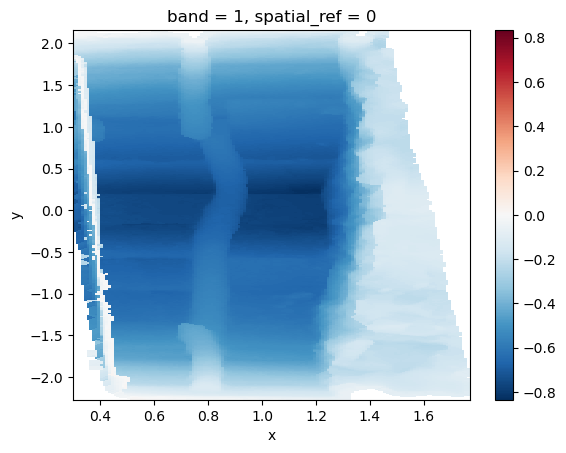

In [82]:
bun_no_data.plot()

In [83]:
depth = max_val - bun_no_data

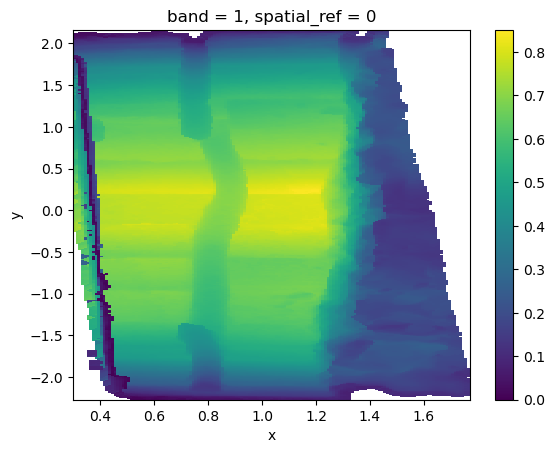

In [84]:
depth.plot()

In [85]:
sum_depth = depth.sum().item()

In [86]:
print(sum_depth)

26623.408203125


In [87]:
volume_pixel = res_x*res_x

In [88]:
volume_bun = volume_pixel*sum_depth

In [89]:
print(volume_bun)

2.6623408203125
